# Haloaromatics: computational workflow and QSAR analysis

This notebook recreates the analysis of the project in Python, step by step, from the scraped Gaussian results to the QSARs:

1. The pipeline on Sherlock (commands only; the calculations are not run here)
2. Species and reactions
3. Scraped data and quality control
4. Reaction free energies, Savéant barriers and descriptors
5. Experimental rate constants
6. Single-descriptor QSARs
7. Example figure: two-electron reduction free energy
8. Multiple-linear-regression QSARs with training/test splits
9. Rebuilding the workbooks

Rate constants were measured at −2.0 V vs SHE (uncompensated potential, without iR-drop compensation). All methods, constants and thresholds come from `config.py`; the code lives in `haloaro/`. Run it from the project's `.venv` (`.venv/bin/jupyter lab`) after `git pull`, so that `results/raw/` holds the latest scrape.

In [1]:
import os, sys, csv, json
from pathlib import Path
from collections import Counter

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "figures"))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import config as C
from haloaro import thermo, descriptors, correlations, mlr, plotting
from haloaro.stages import STAGES, SPECIES, REACTIONS, jobs
pd.set_option("display.max_columns", 30); pd.set_option("display.width", 200)
print("project root:", ROOT)
print("levels:", list(C.LEVELS))

project root: /private/tmp/claude-501/-Users-jonaslapier-Documents-PhD-Sherlock/b0097c9b-c853-4ba9-b441-49658758c89c/scratchpad/qall
levels: ['b3lyp_gas', 'b3lyp_smd', 'm062x_gas', 'm062x_smd']


## 1. Pipeline on Sherlock

Gaussian 16 jobs run on Sherlock through `hx.py`, from `$GROUP_HOME/Haloaromatics` (the checkpoints are too large for `$HOME`):

| stage | what | command |
|---|---|---|
| `am1` | AM1 pre-optimisation | `python3 hx.py generate am1 && python3 hx.py submit am1 --serial --time 0-00:30:00` |
| `optfreq` | Opt + Freq at B3LYP and M06-2X, 6-311++G(d), gas and SMD(water) | `python3 hx.py generate optfreq && python3 hx.py submit optfreq` |
| `sp` | vertical anion/cation/neutral single points, CM5/Hirshfeld, Wiberg | `python3 hx.py generate sp && python3 hx.py submit sp` |
| `tsscan`, `ts` | relaxed C–X scans of the radical anion and TS searches (M06-2X) | `python3 hx.py generate tsscan && python3 hx.py submit tsscan` |
| status / retry | QC and automatic fixes (3-try cap) | `python3 hx.py status all`, `python3 hx.py retry <stage> --only <job>` |
| scrape | logs → `results/raw/<stage>.csv` | `python3 hx.py scrape all` |

`compile` (reactions, barriers, descriptors, correlations, figures, workbook) runs on the Mac with `.venv/bin/python hx.py compile`. The rest of this notebook does what `compile` does, one step at a time.

## 2. Species and reactions

In [2]:
kinds = Counter(s.kind for s in SPECIES.values())
print(pd.Series(kinds, name="species").to_string())
print(f"\n{len(REACTIONS)} symmetry-unique dehalogenation reactions (C–X bonds)")
pd.DataFrame([{"stage": n, "jobs": len(jobs(st))} for n, st in STAGES.items()]).set_index("stage").T

parent           33
halide            2
halogen_atom      2
radical_anion    26
aryl_radical     46
aryl_anion       46
ts               47

47 symmetry-unique dehalogenation reactions (C–X bonds)


stage,am1,b3lyp_gas,b3lyp_smd,m062x_gas,m062x_smd,tsscan_m062x_gas,ts_m062x_gas,tsscan_m062x_smd,ts_m062x_smd,sp_b3lyp_gas,sp_b3lyp_smd,sp_m062x_gas,sp_m062x_smd
jobs,151,155,155,155,155,47,47,47,47,133,133,133,133


In [3]:
pd.DataFrame([vars(r) for r in REACTIONS]).head(8)

,parent,radical_anion,site,degeneracy,halogen,aryl_radical,aryl_anion,hydro_product,ts
0,ClBz_1,ClBz_1_RA,1,1,Cl,Ph_rad,Ph_anion,Bz,TS_ClBz_1_x1
1,ClBz_12,ClBz_12_RA,1,2,Cl,ClPh_2_rad,ClPh_2_anion,ClBz_1,TS_ClBz_12_x1
2,ClBz_13,ClBz_13_RA,1,2,Cl,ClPh_3_rad,ClPh_3_anion,ClBz_1,TS_ClBz_13_x1
3,ClBz_14,ClBz_14_RA,1,2,Cl,ClPh_4_rad,ClPh_4_anion,ClBz_1,TS_ClBz_14_x1
4,ClBz_123,ClBz_123_RA,1,2,Cl,ClPh_23_rad,ClPh_23_anion,ClBz_12,TS_ClBz_123_x1
5,ClBz_123,ClBz_123_RA,2,1,Cl,ClPh_26_rad,ClPh_26_anion,ClBz_13,TS_ClBz_123_x2
6,ClBz_124,ClBz_124_RA,1,1,Cl,ClPh_24_rad,ClPh_24_anion,ClBz_13,TS_ClBz_124_x1
7,ClBz_124,ClBz_124_RA,2,1,Cl,ClPh_25_rad,ClPh_25_anion,ClBz_14,TS_ClBz_124_x2


## 3. Scraped data and quality control
`results/raw/<stage>.csv` holds one row per job with energies, orbital energies, ⟨S²⟩, imaginary frequencies and the QC status (`ok`, `warn`, `fail`). Radical anions are classified by their longest C–X bond (π, bent σ, or dissociated).

In [4]:
RAW = Path("results/raw")
raw = {st: pd.read_csv(f) for st in STAGES if (f := RAW / f"{st}.csv").exists() and f.stat().st_size}
qc = pd.DataFrame({st: df["status"].value_counts() for st, df in raw.items()}).fillna(0).astype(int).T
qc

status,fail,incomplete,missing,ok,warn
am1,0,0,0,151,0
b3lyp_gas,0,0,0,132,23
b3lyp_smd,1,0,0,132,22
m062x_gas,0,0,0,134,21
m062x_smd,0,0,0,136,19
tsscan_m062x_gas,0,0,0,31,0
ts_m062x_gas,0,0,1,0,0
tsscan_m062x_smd,2,4,0,17,0
sp_b3lyp_gas,0,0,0,99,0
sp_b3lyp_smd,0,0,0,99,0


In [5]:
ra = pd.concat([df.assign(level=lv) for lv, df in raw.items() if lv in C.LEVELS], ignore_index=True)
ra = ra[ra["kind"] == "radical_anion"]
pd.crosstab(ra["name"].str.replace("_RA", ""), ra["level"], values=ra["RA_state"], aggfunc="first")

level,b3lyp_gas,b3lyp_smd,m062x_gas,m062x_smd
name,,,,
BDE_245_24,dissociated,dissociated,sigma_bent,sigma_bent
BDE_24_24,dissociated,dissociated,dissociated,dissociated
BrBz_1,dissociated,dissociated,dissociated,dissociated
BrBz_12,dissociated,dissociated,dissociated,dissociated
BrBz_123,dissociated,dissociated,dissociated,dissociated
BrBz_1234,elongated,sigma_bent,sigma_bent,sigma_bent
BrBz_12345,elongated,sigma_bent,sigma_bent,sigma_bent
BrBz_123456,pi,pi,pi,sigma_bent
BrBz_1235,sigma_bent,dissociated,sigma_bent,dissociated


## 4. Reaction free energies, Savéant barriers and descriptors
The same functions `hx.py compile` uses: `thermo.reaction_table` (ΔG and E° of each step per C–X bond), `thermo.det_table` (C–X bond energies and Savéant concerted barriers), `descriptors.molecular_table` and `descriptors.site_table`.

In [6]:
tab, species_rows = {}, []
for sn, st in STAGES.items():
    f = RAW / f"{sn}.csv"
    if not f.exists() or f.stat().st_size == 0:
        continue
    for r in csv.DictReader(open(f)):
        tab[(sn if st.kind in ("ts", "tsscan") else r["level"], r["name"])] = r
atoms = {}
for sn, st in STAGES.items():
    f = RAW / f"{sn}_atoms.json"
    if f.exists() and st.kind in ("optfreq", "sp"):
        for name, v in json.loads(f.read_text()).items():
            atoms[(st.level, name)] = v

rx = thermo.reaction_table(tab, REACTIONS, SPECIES)
det = thermo.det_table(tab, REACTIONS)
ts = thermo.ts_table(tab, REACTIONS)
mol, lam_i = descriptors.molecular_table(tab, SPECIES, rx)
path = thermo.pathway_table(rx, ts, det, lam_i)
sites = descriptors.site_table(tab, atoms, SPECIES, REACTIONS, rx, ts, det)
rx_df = pd.DataFrame(rx)
cols = ["level", "parent", "site", "RA_state", "dG_ET_any_kcal", "dG_frag_any_kcal", "dG_1e_kcal",
        "dG_2e_carbanion_kcal", "E_2e_carbanion_V"]
rx_df[rx_df["parent"].isin(["BrBz_1", "BrBz_123456", "ClBz_123456", "BDE_245_24"])][cols].head(12)

,level,parent,site,RA_state,dG_ET_any_kcal,dG_frag_any_kcal,dG_1e_kcal,dG_2e_carbanion_kcal,E_2e_carbanion_V
19,b3lyp_gas,ClBz_123456,1,pi,-34.01,22.38,-11.63,-83.08,NaN
20,b3lyp_gas,BrBz_1,1,dissociated,-12.91,-0.45,-13.36,-37.30,NaN
39,b3lyp_gas,BrBz_123456,1,pi,-46.83,22.11,-24.73,-97.23,NaN
42,b3lyp_gas,BDE_245_24,2,dissociated,-23.93,9.60,-14.33,-77.54,NaN
43,b3lyp_gas,BDE_245_24,4,dissociated,-23.93,7.54,-16.39,-75.52,NaN
44,b3lyp_gas,BDE_245_24,5,dissociated,-23.93,7.55,-16.38,-74.66,NaN
45,b3lyp_gas,BDE_245_24,2p,dissociated,-23.93,8.25,-15.68,-85.28,NaN
46,b3lyp_gas,BDE_245_24,4p,dissociated,-23.93,10.18,-13.75,-60.18,NaN
66,b3lyp_smd,ClBz_123456,1,sigma_bent,-73.50,-0.53,-74.03,-187.46,-0.216
67,b3lyp_smd,BrBz_1,1,dissociated,-60.42,-3.16,-63.58,-147.23,-1.089


In [7]:
mol_df = pd.DataFrame(mol)
mol_df[mol_df["level"] == "m062x_gas"][["parent", "n_X", "LUMO_eV", "VEA_eV", "omega_dSCF_eV", "RA_state",
                                        "dG_ET_kcal", "min_dG_2e_carbanion_kcal"]].head(16)

,parent,n_X,LUMO_eV,VEA_eV,omega_dSCF_eV,RA_state,dG_ET_kcal,min_dG_2e_carbanion_kcal
66,Bz,0,-0.003,-0.885,0.890,NaN,NaN,NaN
67,ClBz_1,1,-0.093,-0.783,0.902,pi,17.53,-21.67
68,ClBz_12,2,-0.158,-0.791,0.905,dissociated,NaN,-39.66
69,ClBz_13,2,-0.212,-0.733,0.931,pi,6.75,-32.84
70,ClBz_14,2,-0.236,-0.720,0.911,pi,6.50,-30.91
71,ClBz_123,3,-0.385,-0.546,1.003,sigma_bent,-10.37,-55.30
72,ClBz_124,3,-0.491,-0.399,1.025,sigma_bent,-9.94,-48.62
73,ClBz_135,3,-0.486,-0.384,1.075,dissociated,NaN,-43.12
74,ClBz_1234,4,-0.608,-0.219,1.097,sigma_bent,-15.59,-62.43
75,ClBz_1235,4,-0.700,-0.126,1.137,sigma_bent,-15.48,-61.81


## 5. Experimental rate constants
`data/experimental_kobs.csv`: bromobenzenes and PBDEs from LaPier et al., *Environ. Sci. Technol.* 2026, 60, 1346 (Table 1; 1,3-dibromobenzene corrected to 0.0329 h⁻¹); chlorobenzenes unpublished.

In [8]:
kobs = pd.read_csv(C.EXPERIMENTAL_KOBS)
kobs["ln_kobs"] = np.log(kobs["kobs_per_h"])
kobs[["compound", "label", "group", "kobs_per_h", "se_per_h", "ln_kobs", "half_life", "source"]]

,compound,label,group,kobs_per_h,se_per_h,ln_kobs,half_life,source
0,Bromobenzene,MonoBr,bromobenzene,0.002000,0.00021,-6.214608,15 d,"LaPier et al., Environ. Sci. Technol. 2026, 60..."
1,"1,4-Dibromobenzene","1,4-DiBr",bromobenzene,0.012000,0.00140,-4.422849,2.4 d,"LaPier et al., Environ. Sci. Technol. 2026, 60..."
2,"1,3-Dibromobenzene","1,3-DiBr",bromobenzene,0.032900,0.00310,-3.414283,21 h,"LaPier et al., Environ. Sci. Technol. 2026, 60..."
3,"1,2,4-Tribromobenzene","1,2,4-TriBr",bromobenzene,0.550000,0.08200,-0.597837,1.3 h,"LaPier et al., Environ. Sci. Technol. 2026, 60..."
4,"1,3,5-Tribromobenzene","1,3,5-TriBr",bromobenzene,0.900000,0.15000,-0.105361,46 min,"LaPier et al., Environ. Sci. Technol. 2026, 60..."
5,"1,2,4,5-Tetrabromobenzene","1,2,4,5-TetrBr",bromobenzene,2.500000,0.28000,0.916291,17 min,"LaPier et al., Environ. Sci. Technol. 2026, 60..."
6,Hexabromobenzene,HexaBr,bromobenzene,10.000000,1.30000,2.302585,4.2 min,"LaPier et al., Environ. Sci. Technol. 2026, 60..."
7,BDE-47,BDE-47,pbde,0.078000,0.01800,-2.551046,8.9 h,"LaPier et al., Environ. Sci. Technol. 2026, 60..."
8,BDE-99,BDE-99,pbde,0.450000,0.06800,-0.798508,1.5 h,"LaPier et al., Environ. Sci. Technol. 2026, 60..."
9,Hexachlorobenzene,HexaCl,chlorobenzene,4.739304,NaN,1.555890,8.8 min,unpublished


## 6. Single-descriptor QSARs
`correlations.run` fits ln k_obs = slope·x + intercept for every descriptor, level and compound set, and reports R², p, RMSE and leave-one-out Q² (predictive ability within the fitted set), plus the RMSE of predicting the compounds not used in the fit (`pred_RMSE_other_groups`). The bromobenzenes (n = 7) are the training set.

In [9]:
corr, cdata, cpairs, cpred, qsar = correlations.run(mol, rx, det, path, ts, sites)
q = pd.DataFrame(qsar)
q = q[(q["fit_set"] == C.CORR_FIT_GROUP) & (q["descriptor_set"] != "MLR") & q["R2"].notna()]
for c in ("R2", "Q2", "RMSE", "pred_RMSE_other_groups", "p", "n"):
    q[c] = pd.to_numeric(q[c])
q.sort_values("Q2", ascending=False)[["level", "model", "n", "R2", "Q2", "RMSE", "pred_RMSE_other_groups", "p"]].head(12)

,level,model,n,R2,Q2,RMSE,pred_RMSE_other_groups,p
246,m062x_gas,dG ArX.- + e- -> Ar- + X-,7,0.9306,0.8854,0.7541,4.085,0.0004
6,b3lyp_gas,dG ArX.- + e- -> Ar- + X-,7,0.9225,0.8686,0.7966,4.418,0.0006
16,b3lyp_gas,dG Ar. + e- -> Ar-,7,0.9473,0.8653,0.6572,2.671,0.0002
256,m062x_gas,dG Ar. + e- -> Ar-,7,0.9375,0.8531,0.7155,2.831,0.0003
243,m062x_gas,dG ArX + 2e- -> Ar- + X-,7,0.9152,0.7496,0.8333,1.887,0.0007
5,b3lyp_gas,dG ArX.- -> Ar. + X-,7,0.9217,0.7459,0.8009,2.058,0.0006
126,b3lyp_smd,dG ArX.- + e- -> Ar- + X-,7,0.8928,0.7358,0.9370,7.158,0.0013
3,b3lyp_gas,dG ArX + 2e- -> Ar- + X-,7,0.9131,0.7220,0.8438,1.770,0.0008
245,m062x_gas,dG ArX.- -> Ar. + X-,7,0.9175,0.7183,0.8220,1.927,0.0007
1,b3lyp_gas,LUMO of the radical anion ArX.-,7,0.9211,0.7170,0.8039,1.584,0.0006


In [10]:
grid = q.pivot_table(index="model", columns="level", values="Q2")
grid.sort_values("m062x_gas", ascending=False).round(2)

level,b3lyp_gas,b3lyp_smd,m062x_gas,m062x_smd
model,,,,
dG ArX.- + e- -> Ar- + X-,0.87,0.74,0.89,-1.37
dG Ar. + e- -> Ar-,0.87,0.68,0.85,0.71
dG ArX + 2e- -> Ar- + X-,0.72,0.44,0.75,0.54
dG ArX.- -> Ar. + X-,0.75,0.53,0.72,-6.75
weakest Wiberg C-X bond order,0.58,0.67,0.61,0.67
vertical electron affinity,0.37,-0.43,0.49,0.21
number of halogens,0.47,0.47,0.47,0.47
dG ArX + e- -> ArX.-,0.31,-0.25,0.40,-0.95
electrophilicity index (dSCF),-0.05,-1.53,0.24,-0.13


Figures in the project's plot style (`haloaro/plotting.py`): the six best models per level, fitted on the bromobenzenes (filled gray), with the chlorobenzenes (open) and PBDEs (squares) predicted.

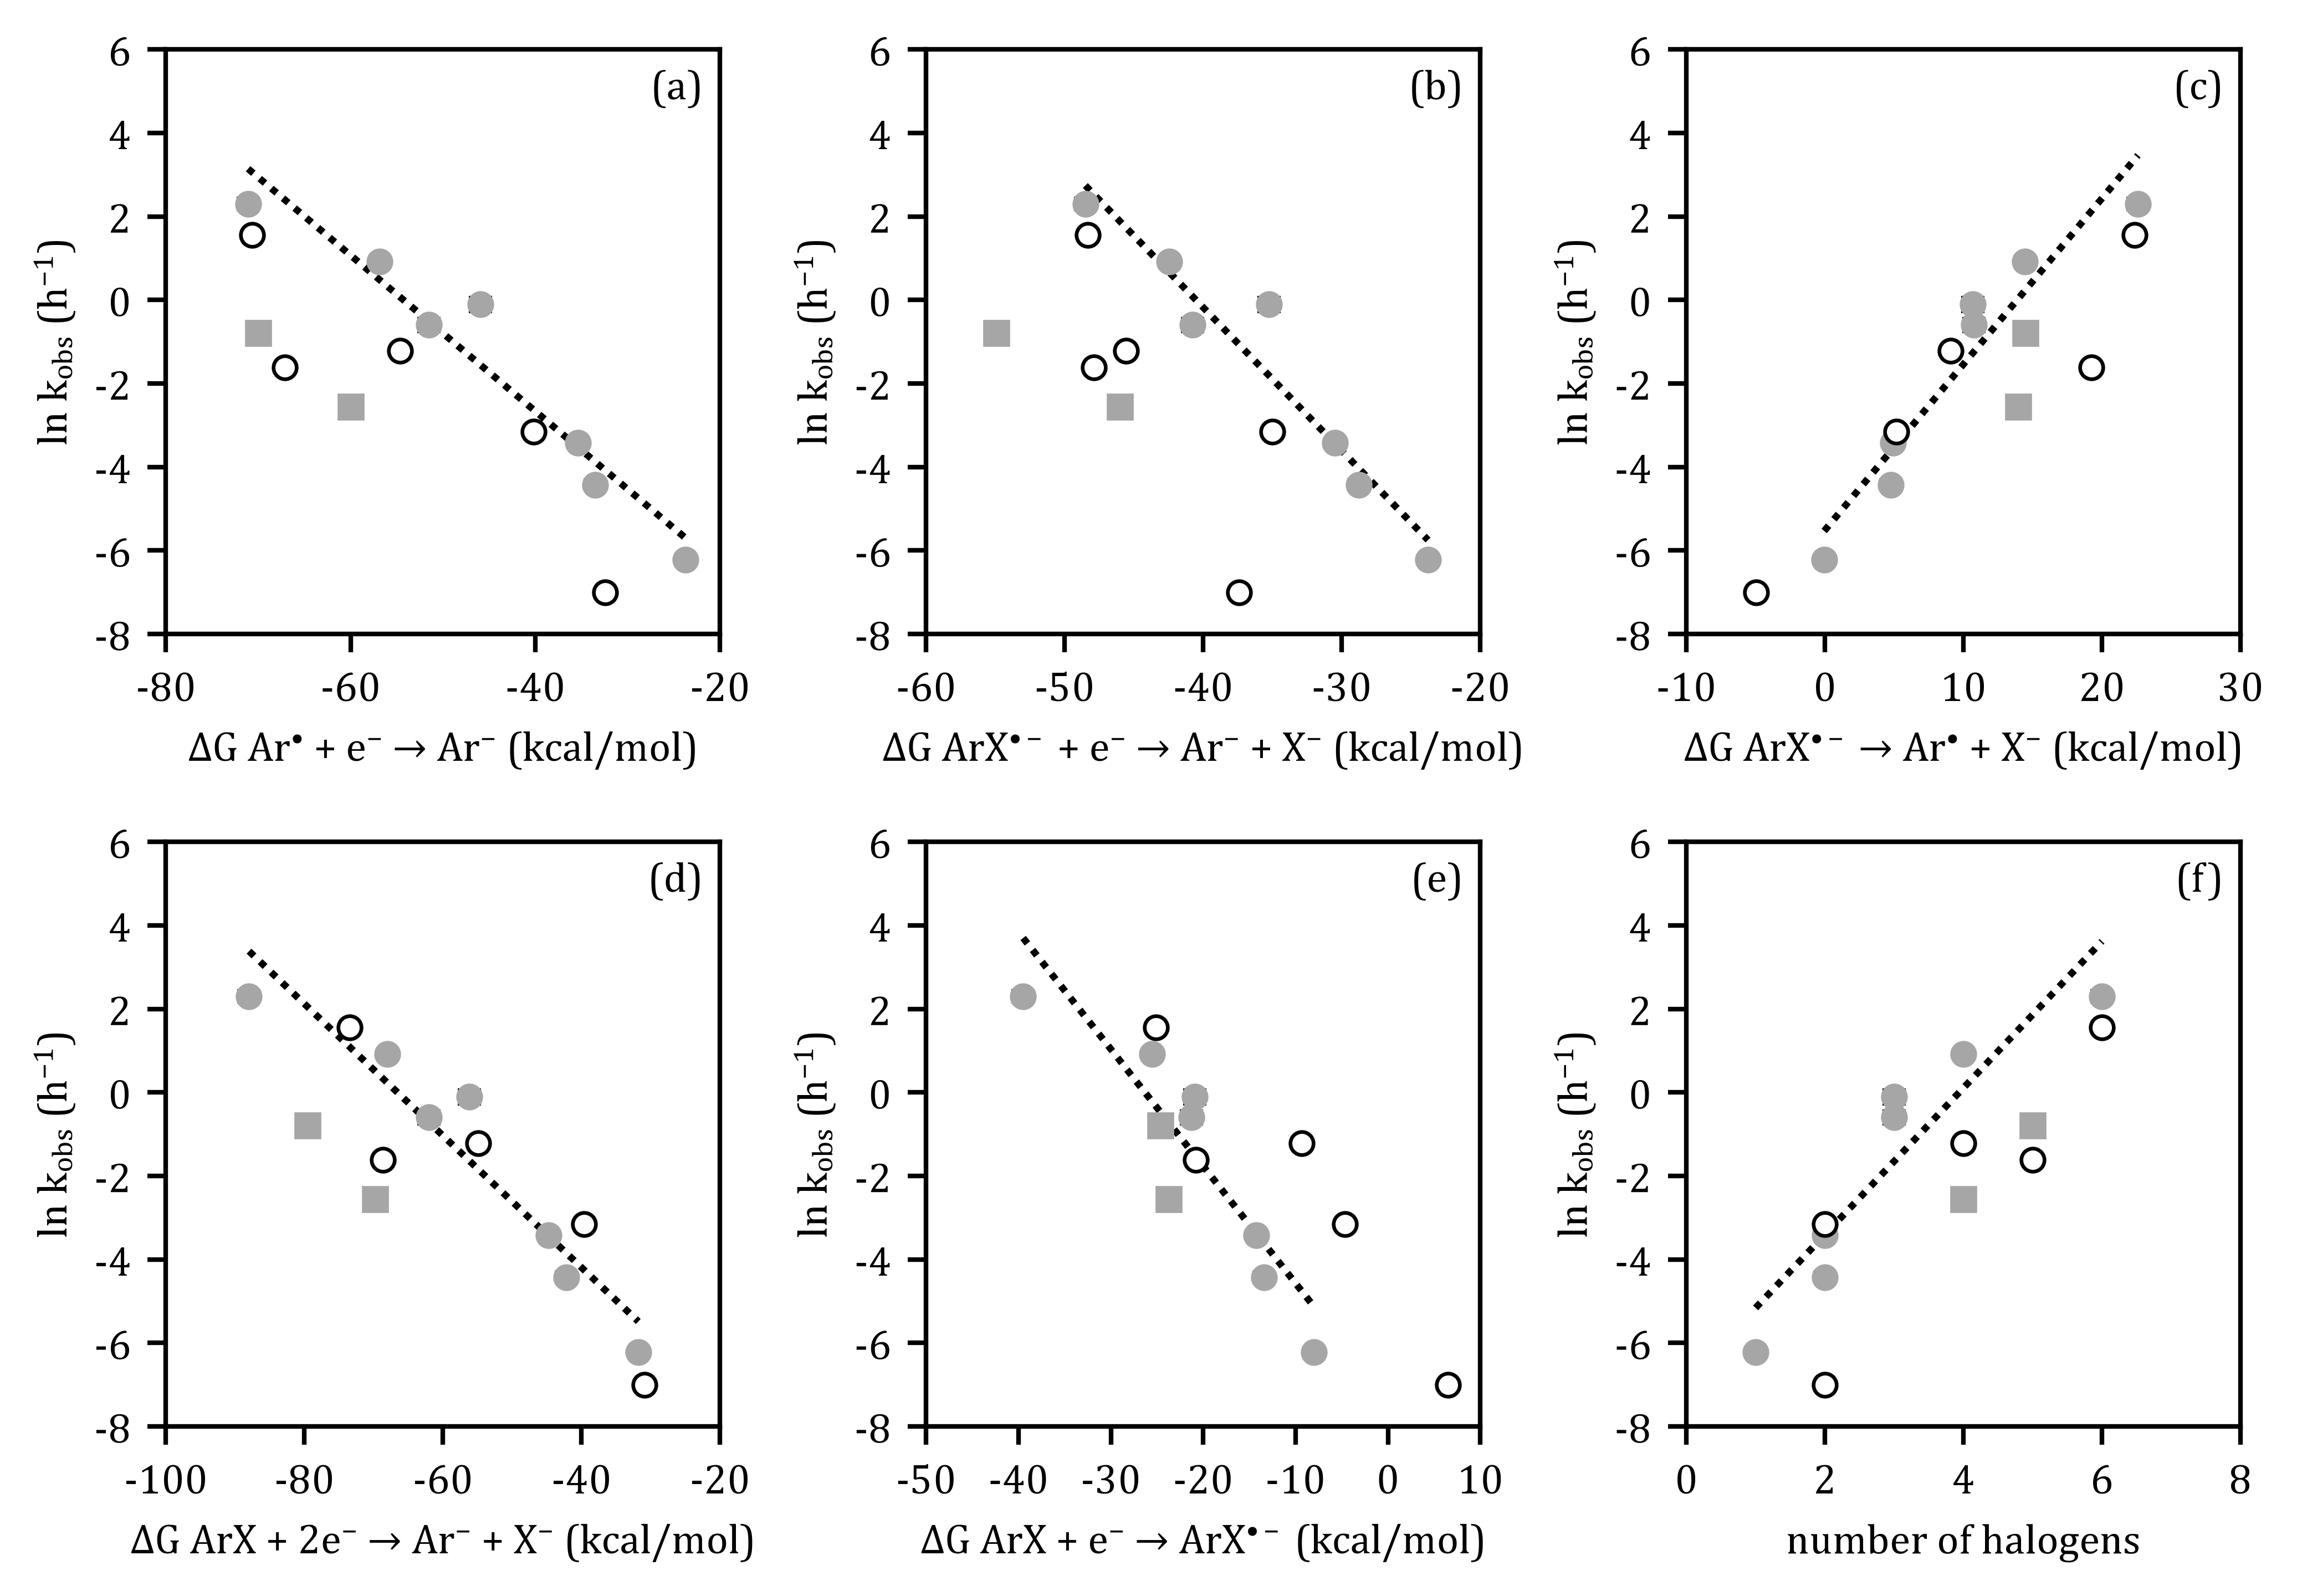

In [11]:
plotting.use_style()
figs = plotting.correlation_figures(qsar, cdata, "results/plots")   # writes PNG/PDF files
%matplotlib inline
from IPython.display import Image, display
display(Image("results/plots/correlations_m062x_gas.png", width=800))

## 7. Example: ln k_obs vs ΔG of ArX + 2e⁻ → Ar⁻ + X⁻ (M06-2X, gas and SMD)

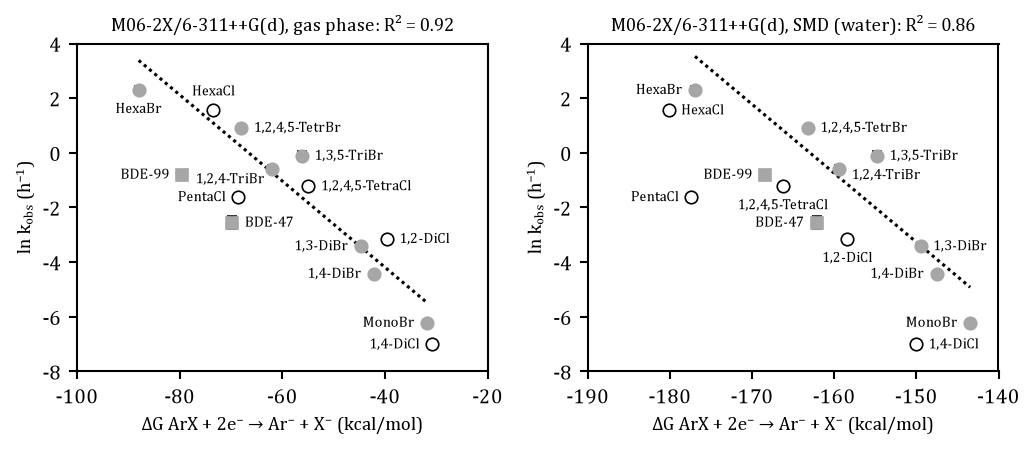

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.1))
panels = []
for ax, lv in zip(axes, ("m062x_gas", "m062x_smd")):
    fit = q[(q["level"] == lv) & (q["descriptors"] == "min_dG_2e_carbanion_kcal")].iloc[0].to_dict()
    pts = plotting._points(cdata, lv, "min_dG_2e_carbanion_kcal")
    drawn, line = plotting._panel(ax, fit, pts, "min_dG_2e_carbanion_kcal", "dG ArX + 2e- -> Ar- + X-",
                                  ([-8, -6, -4, -2, 0, 2, 4], 0), ms=6, fontsize=9)
    ax.set_title(f"{plotting.level_text(lv)}: R² = {fit['R2']:.2f}", fontsize=9)
    panels.append((ax, pts, line))
fig.tight_layout()
for ax, pts, line in panels:          # labels after the layout is final
    plotting._place_labels(fig, ax, pts, line, fontsize=7)
plt.show()

## 8. Multiple-linear-regression QSARs with training/test splits
`haloaro/mlr.py` fits every combination of 1–3 descriptors that have values for all 14 compounds, and scores each on 200 random stratified splits (10 training compounds, 4 test compounds: 2 bromobenzenes, 1 chlorobenzene, 1 PBDE). The test RMSE is pooled over all splits, so a model is judged only on compounds it was not fitted on. Models whose descriptors correlate with |r| > 0.9 are flagged as collinear. A transfer test fits on the bromobenzenes only and predicts the chlorobenzenes and PBDEs. (This cell takes about a minute.)

In [13]:
models, info = mlr.explore(cdata)
m = pd.DataFrame(models)
m["model"] = m["descriptors"].apply(lambda d: " + ".join(d))
ok = m[~m["collinear"]]
print(f"{len(m)} models, {len(ok)} non-collinear; mean-model test RMSE {info['m062x_gas']['RMSE_test_mean_model']:.2f}")
ok[["level", "k", "model", "RMSE_test", "RMSE_test_sd", "Q2_F1", "R2_train", "R2", "RMSE_transfer", "max_abs_r"]].head(10).round(2)

2928 models, 2036 non-collinear; mean-model test RMSE 2.68


,level,k,model,RMSE_test,RMSE_test_sd,Q2_F1,R2_train,R2,RMSE_transfer,max_abs_r
0,m062x_smd,3,LUMO_eV + min_dG0_act_concerted_kcal + min_wib...,1.13,0.37,0.82,0.90,0.90,8.21,0.55
1,m062x_smd,2,min_dG0_act_concerted_kcal + min_wiberg_CX_parent,1.14,0.26,0.82,0.89,0.88,6.57,0.45
2,m062x_smd,3,LUMO_RA_eV + min_dG0_act_concerted_kcal + min_...,1.15,0.32,0.82,0.92,0.91,5.07,0.53
3,b3lyp_gas,2,LUMO_RA_eV + min_wiberg_CX_parent,1.17,0.32,0.81,0.87,0.86,2.00,0.25
5,m062x_gas,3,min_dG_rad_red_kcal + min_BDE_kcal + min_wiber...,1.18,0.29,0.81,0.89,0.89,10.47,0.68
7,m062x_gas,3,min_dG_2e_carbanion_kcal + min_BDE_kcal + min_...,1.19,0.29,0.80,0.89,0.89,11.43,0.68
9,m062x_gas,2,dG_ET_any_kcal + min_wiberg_CX_parent,1.21,0.28,0.80,0.87,0.86,1.62,0.11
10,b3lyp_gas,3,LUMO_RA_eV + n_X + min_wiberg_CX_parent,1.21,0.36,0.80,0.88,0.87,1.28,0.84
12,m062x_smd,3,min_dG0_act_concerted_kcal + max_fplus_CX + mi...,1.21,0.35,0.80,0.91,0.90,9.82,0.82
14,m062x_smd,3,LUMO_eV + eff_dG_act_concerted_kcal @ -2.00 V ...,1.22,0.34,0.79,0.92,0.91,5.33,0.82


In [14]:
print("best per number of descriptors:")
display(ok.groupby("k").head(1)[["level", "k", "model", "RMSE_test", "RMSE_test_sd", "Q2_F1"]].round(2))
print("descriptor frequency in the top 30 models:")
Counter(d for ds in ok.head(30)["descriptors"] for d in ds).most_common(8)

best per number of descriptors:


,level,k,model,RMSE_test,RMSE_test_sd,Q2_F1
0,m062x_smd,3,LUMO_eV + min_dG0_act_concerted_kcal + min_wib...,1.13,0.37,0.82
1,m062x_smd,2,min_dG0_act_concerted_kcal + min_wiberg_CX_parent,1.14,0.26,0.82
47,b3lyp_gas,1,LUMO_RA_eV,1.31,0.24,0.76


descriptor frequency in the top 30 models:


[('min_wiberg_CX_parent', 27),
 ('min_dG0_act_concerted_kcal', 9),
 ('LUMO_RA_eV', 8),
 ('min_dG_rad_red_kcal', 6),
 ('min_BDE_kcal', 6),
 ('min_dG_2e_carbanion_kcal', 6),
 ('min_dG_RA_2e_any_kcal', 4),
 ('LUMO_eV', 3)]

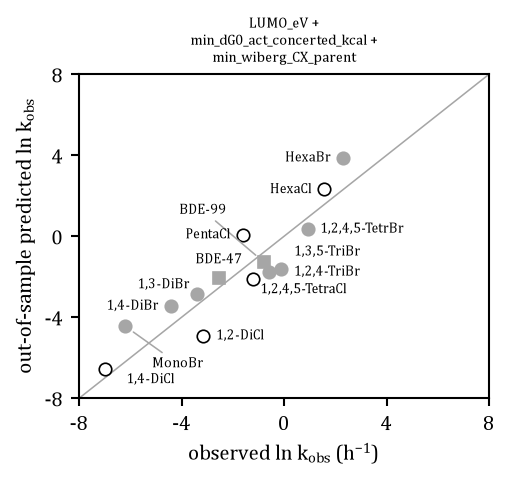

In [15]:
best = ok.iloc[0]
pred = mlr.oos_predictions(cdata, best["level"], best["descriptors"])
fig, ax = plt.subplots(figsize=(3.5, 3.3))
pts = [{"x": yo, "y": yp, "group": r["group"], "label": r["label"], "yerr": None} for r, yo, yp, n in pred]
plotting._series(ax, pts, 6)
one = ax.plot([-8, 8], [-8, 8], color="#a6a6a6", lw=0.75, zorder=1)[0]      # 1:1 line
for a in ("x", "y"):
    plotting._set_ticks(ax, a, [-8, -4, 0, 4, 8], 0)
ax.set_xlabel("observed ln k$_\\mathrm{obs}$ (h$^\\mathrm{−1}$)"); ax.set_ylabel("out-of-sample predicted ln k$_\\mathrm{obs}$")
ax.set_title(best["model"].replace(" + ", " +\n"), fontsize=7)
fig.tight_layout(); plotting._place_labels(fig, ax, pts, one, fontsize=6.5); plt.show()

Interpretation (details and sources in `figures/QSAR_MLR_exploration.xlsx`, Interpretation tab): the Wiberg C–X bond order recurs in the best mixed-training models because it tracks ln k_obs within each halogen family but is offset between them, so it pairs with a halogen-sensitive term (Savéant intrinsic barrier, C–X bond energy, LUMO or a reduction free energy). Two descriptors are the most these 14 compounds support. Trained on bromobenzenes alone, frontier-orbital and Fukui descriptors transfer best to the chlorobenzenes and PBDEs.

## 9. Rebuilding the workbooks
The Excel deliverables are built by scripts in `figures/` from the compiled results (uncomment to run):

In [16]:
# !python hx.py compile
# !python figures/qsar_workbook.py figures/QSAR_workbook.xlsx
# !python figures/qsar_mlr_explore.py figures/QSAR_MLR_exploration.xlsx
print(sorted(p.name for p in Path("figures").glob("*.xlsx")))

['M062X_QSAR.xlsx']
